In [1]:
import setup
from importlib import reload
reload(setup)
from setup import *

# 1D Fickian diffusion 
henry_constant = 1e-3 * 1000 # mol/m^3/atm for CO in water at 293.15K 
diffusion_coefficient = 1.91e-9 # m2/s for CO in water at 293.15K 
A_site = F * 1e-4 / (210e-6 * N_A) # Surface area of a single Pt site: 1cm2 = 210uC (HUPD)
delta_BL_micron = 1e-6 # Setting the denominator to 1 micron to allow for delta_BL to be in microns
k1_fick = diffusion_coefficient * henry_constant * N_A * A_site / delta_BL_micron
log_k1_fick = np.log(k1_fick)

# ER 2 

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.41,31
,3000,0,0.41,15
,3000,0,0.39,15
,3000,0,0.41,15


Computed from 4000 posterior samples and 2324 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  4569.12    64.86
p_loo       12.28        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     2324  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



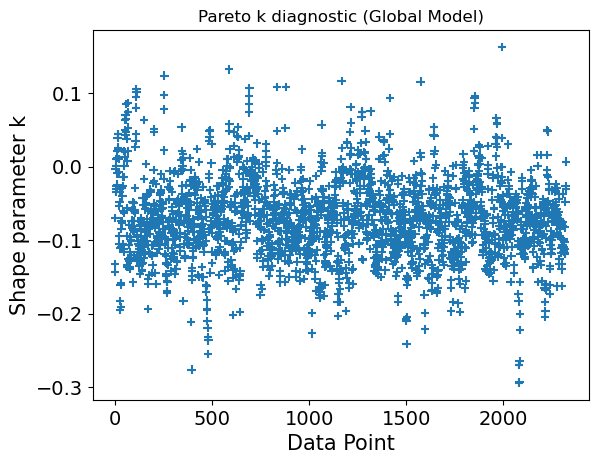

In [2]:
with pm.Model() as ER_2:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH- -> COOH* + (e-) (RDS)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)   
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2 = Gact2_0 - beta_2*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))
    theta_empty = pm.Deterministic('theta_empty', pt.exp(log_theta))

    # Rate expression
    log_rate = log_k2 + log_theta_CO + np.log(C_KOH_in)
    rate = observables(log_rate) 

trace_ER_2, loo_ER_2 = fit_and_evaluate(ER_2)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.108  0.001  -0.110   -0.105      0.000    0.000    2883.0    2580.0    1.0
deltaG4_0   0.048  0.006   0.037    0.058      0.000    0.000    2448.0    2530.0    1.0
Gact2_0     0.752  0.000   0.751    0.752      0.000    0.000    2953.0    2717.0    1.0
beta_2      0.255  0.003   0.248    0.261      0.000    0.000    3040.0    3036.0    1.0
sigma_rel   0.199  0.010   0.180    0.219      0.000    0.000    1901.0    2249.0    1.0
sigma_base  0.005  0.000   0.004    0.006      0.000    0.000    2552.0    2368.0    1.0
exponent    1.372  0.044   1.298    1.464      0.001    0.001    1877.0    2097.0    1.0


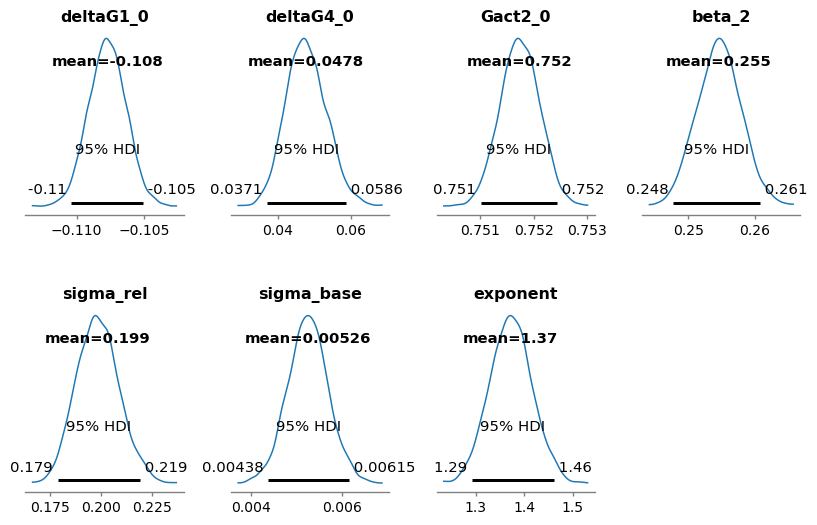

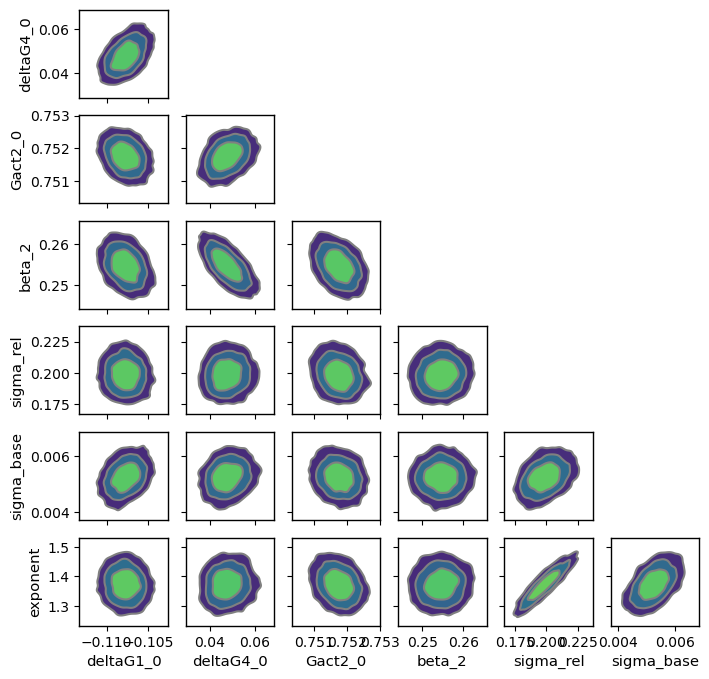

Sampling: [rate]


rate: 0.817


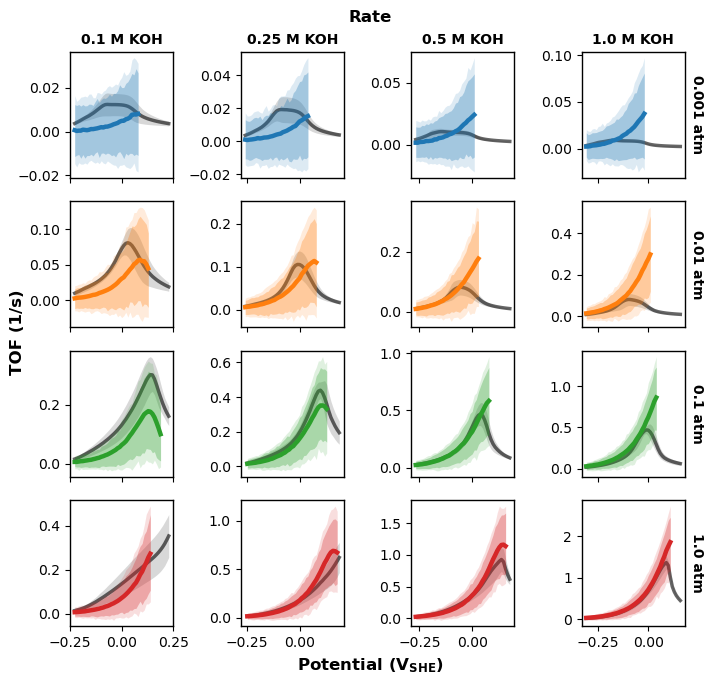

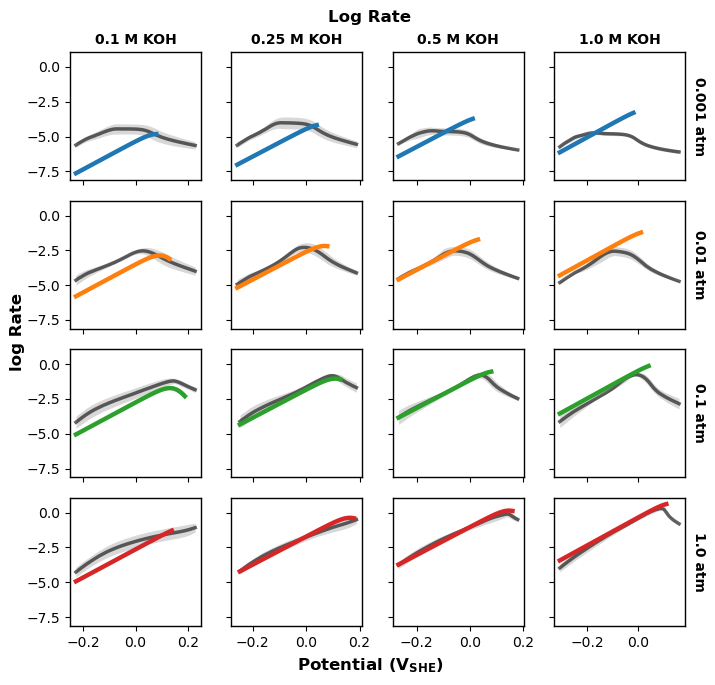

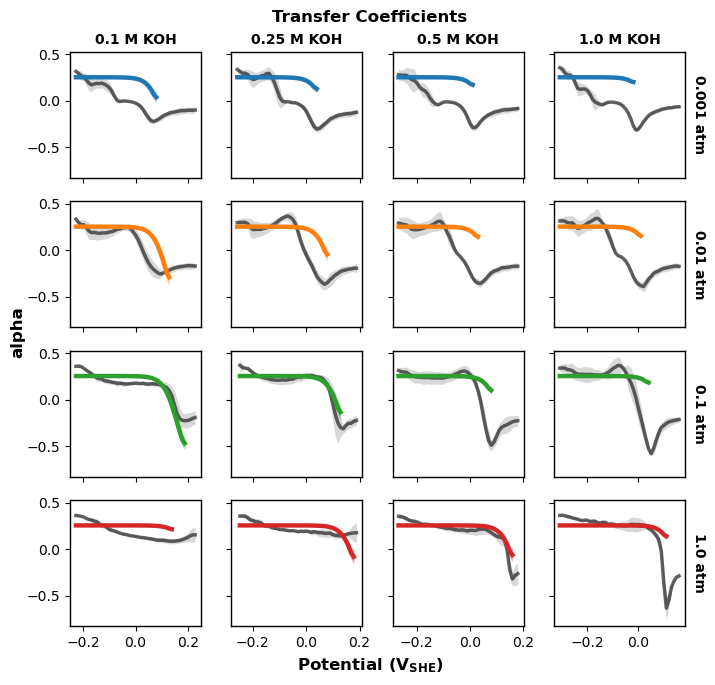

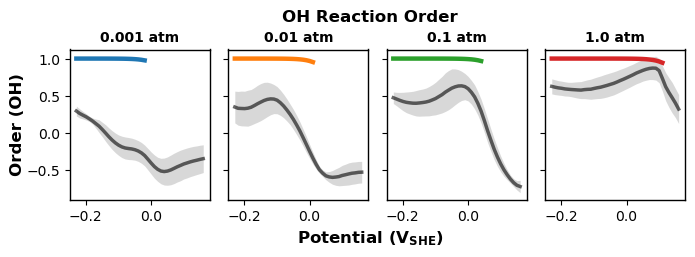

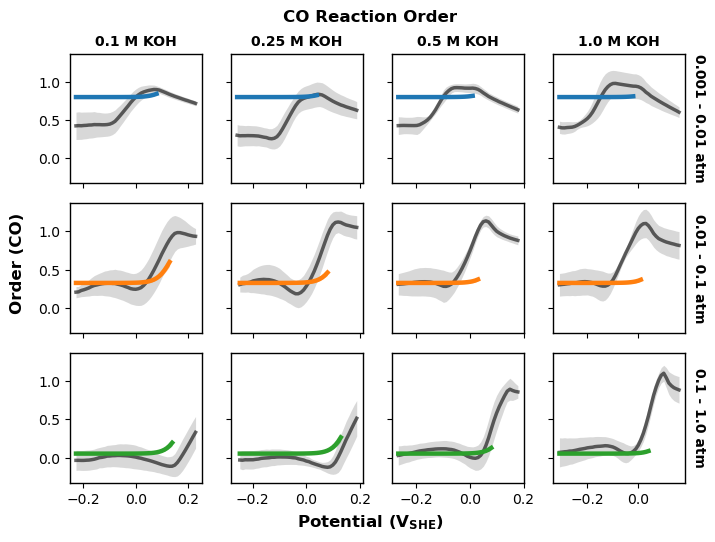

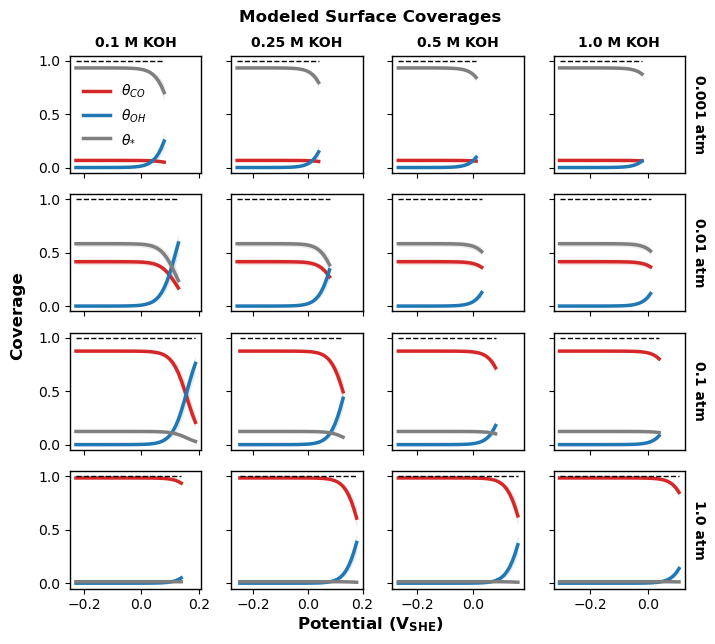

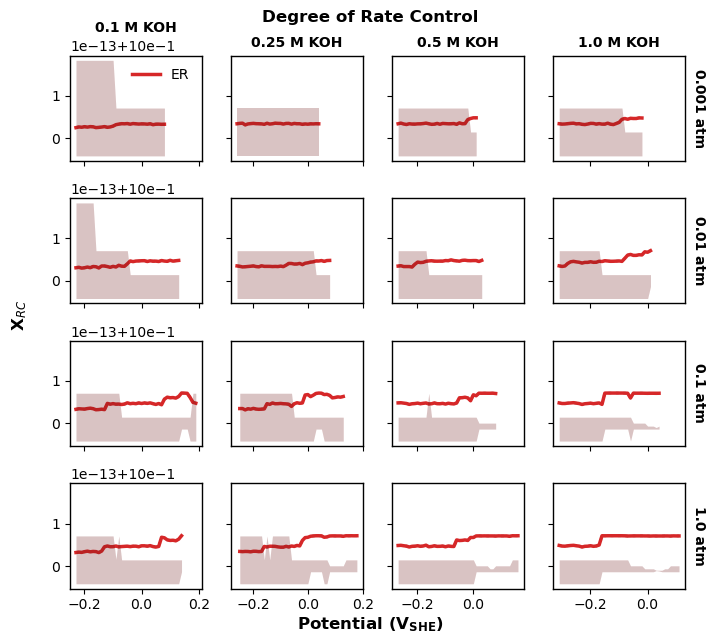

In [3]:
ppc_ER_2 = plot_posteriors(trace_ER_2, ER_2)
plot_model_fits(trace_ER_2, ppc_ER_2); plot_coverages(trace_ER_2)
plot_drc(ER_2, trace_ER_2, perturb_vars=['Gact2_0'], perturb_labels=['ER'])

# ER 1 2

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.43,15
,3000,0,0.43,15
,3000,0,0.43,23
,3000,0,0.45,7


Computed from 4000 posterior samples and 2324 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  5169.68    72.58
p_loo        8.30        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     2324  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



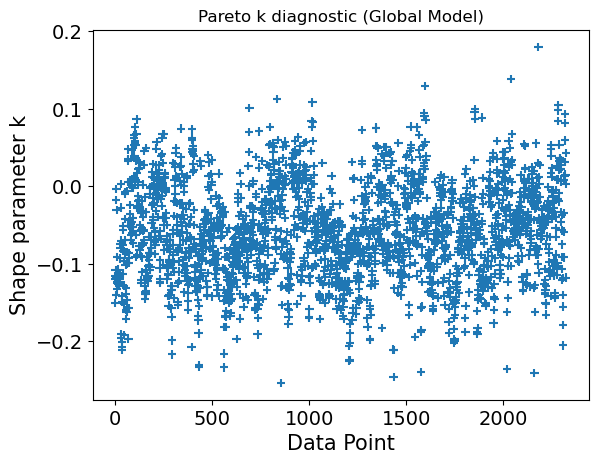

In [4]:
with pm.Model() as ER_1_2: 
    '''
    1. CO + * -> CO* (Fick) (Irr) (SSA)
    2. CO* + OH- -> COOH* + (e-) (SSA)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.1) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    Gact2_0 = pm.Normal('Gact2_0', mu=0.75, sigma=0.1) # at 0V_SHE
    delta_BL = pm.TruncatedNormal('delta_BL', mu=10, sigma=5, lower=0) # in microns

    # Thermodynamics 
    deltaG4 = deltaG4_0 - E_in
    Gact2 = Gact2_0 - beta_2*E_in
    log_K4 = -deltaG4/(kb_eV*T)
    log_k1 = log_k1_fick - pt.log(delta_BL)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_k1 + np.log(P_CO_in) - (log_k2 + np.log(C_KOH_in))
    term_OH = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))
    theta_empty = pm.Deterministic('theta_empty', pt.exp(log_theta))

    # Rate expression
    log_rate = log_k2 + np.log(C_KOH_in) + log_theta_CO 
    rate = observables(log_rate)

trace_ER_1_2, loo_ER_1_2 = fit_and_evaluate(ER_1_2)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG4_0   0.089  0.003   0.084    0.094      0.000    0.000    3149.0    2998.0    1.0
Gact2_0     0.747  0.000   0.746    0.748      0.000    0.000    2305.0    2439.0    1.0
beta_2      0.277  0.003   0.271    0.283      0.000    0.000    2562.0    2689.0    1.0
delta_BL    9.455  0.221   9.051    9.874      0.004    0.003    3821.0    3252.0    1.0
sigma_rel   0.214  0.010   0.196    0.232      0.000    0.000    1245.0    2069.0    1.0
sigma_base  0.000  0.000   0.000    0.001      0.000    0.000    2784.0    1508.0    1.0
exponent    1.606  0.030   1.549    1.661      0.001    0.001    1224.0    2097.0    1.0


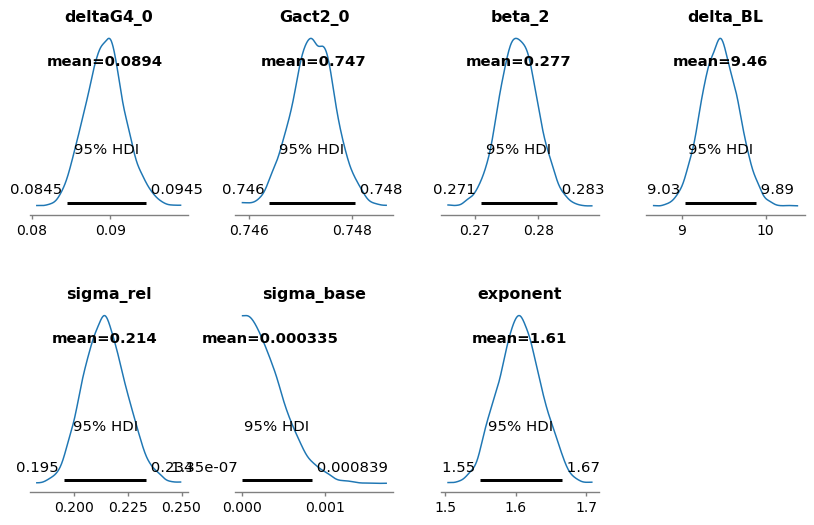

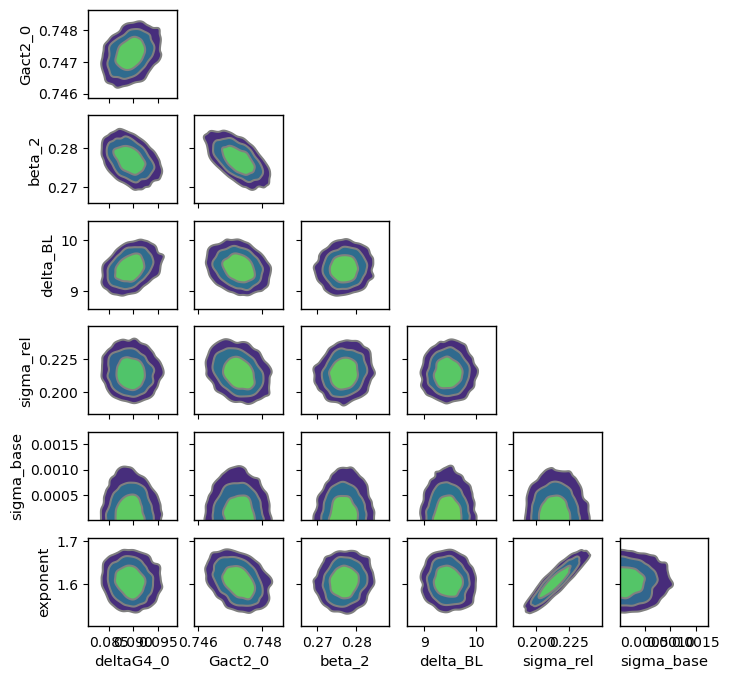

Sampling: [rate]


rate: 0.831


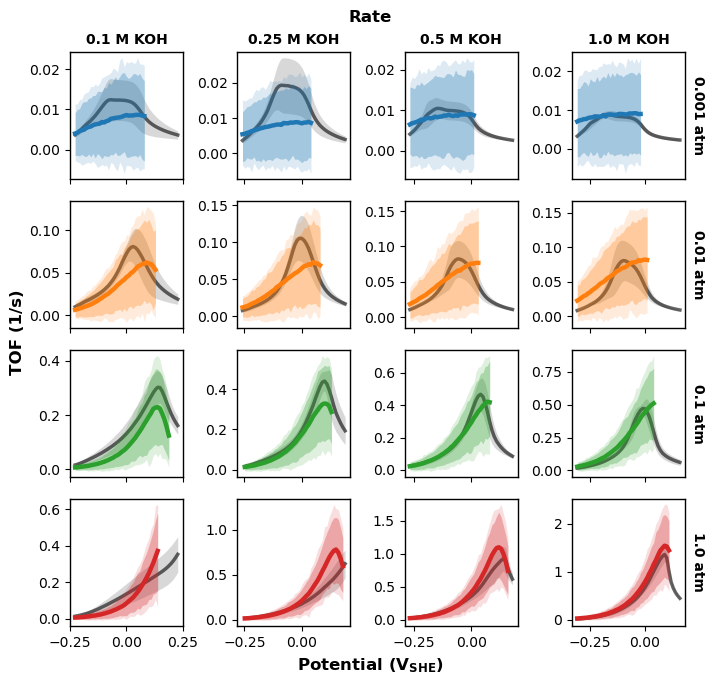

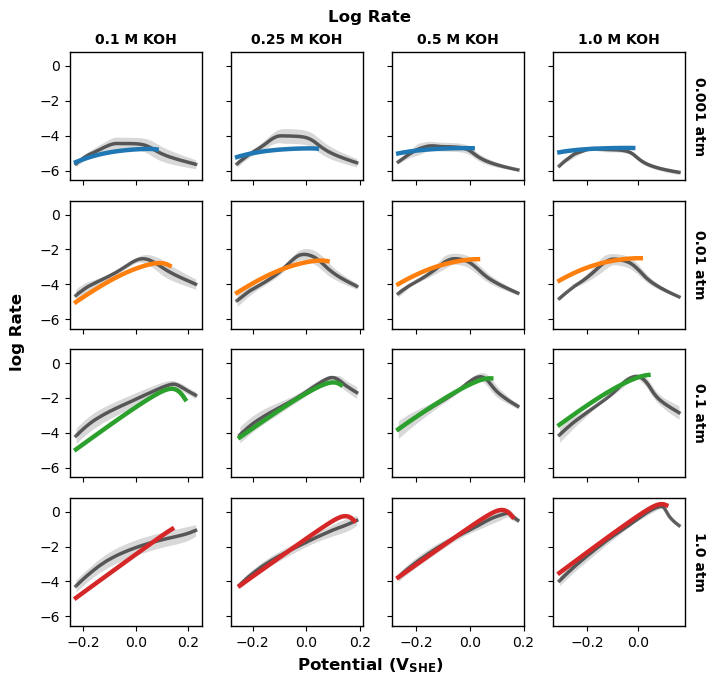

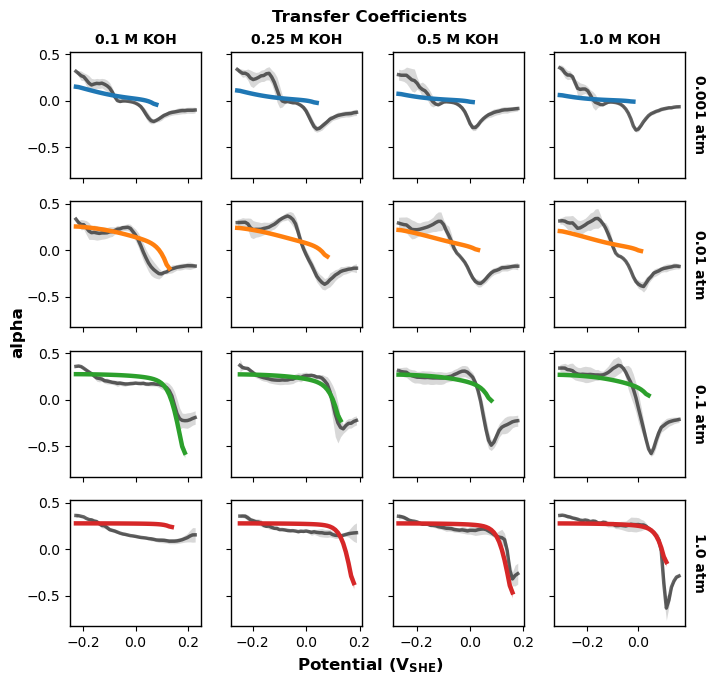

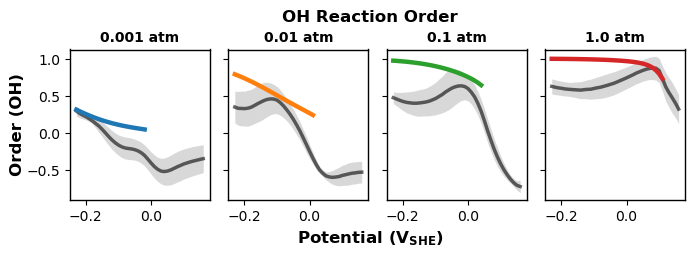

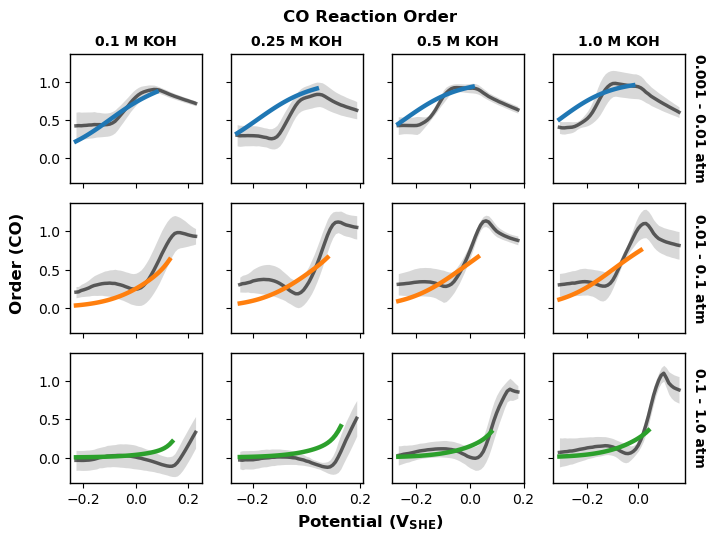

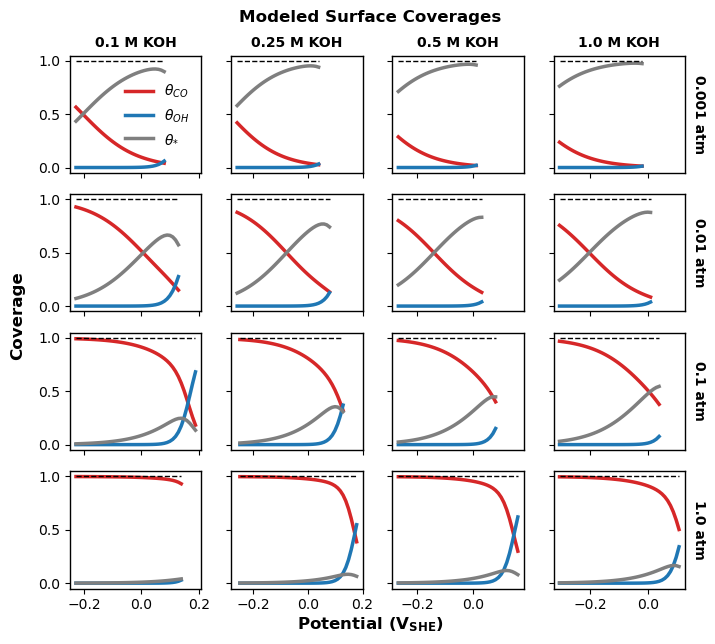

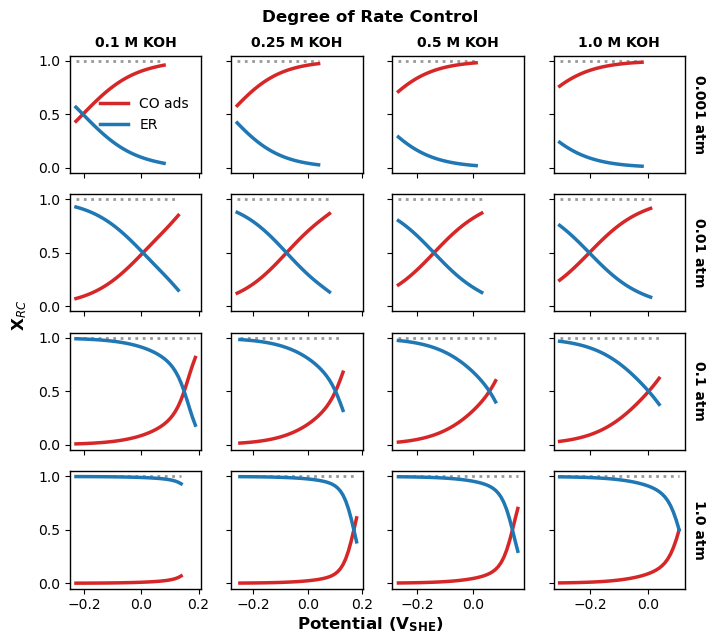

In [5]:
ppc_ER_1_2 = plot_posteriors(trace_ER_1_2, ER_1_2)
plot_model_fits(trace_ER_1_2, ppc_ER_1_2); plot_coverages(trace_ER_1_2)
plot_drc(ER_1_2, trace_ER_1_2, perturb_vars=['delta_BL', 'Gact2_0'], perturb_labels=['CO ads', 'ER'], 
         var_types={'delta_BL': 'resistance', 'Gact2_0': 'Gact'})

# ER 1 2 Kinetics

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.17,31
,3000,0,0.15,31
,3000,0,0.17,31
,3000,0,0.16,31


Computed from 4000 posterior samples and 2324 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  5111.08    69.88
p_loo        7.85        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     2324  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



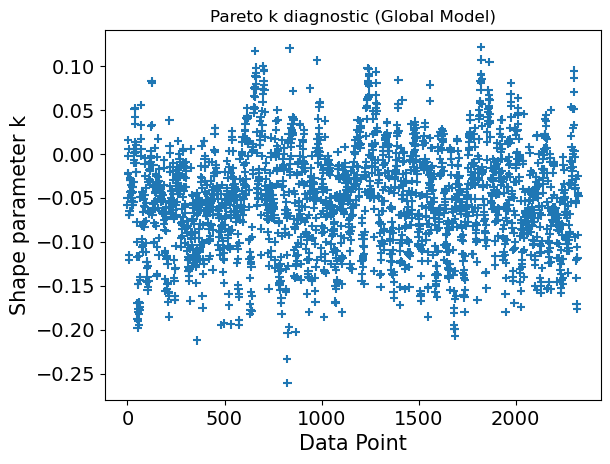

In [6]:
with pm.Model() as ER_1_2_kin: 
    '''
    1. CO + * <-> CO* (Fick) (SSA)
    2. CO* + OH- -> COOH* + (e-) (SSA)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.6, sigma=0.02)
    Gact1_0 = pm.TruncatedNormal('Gact1_0', mu=0.6, sigma=0.2, lower=0, upper=0.8) # Kinetic barrier for adsorption
    deltaG4_0 = pm.TruncatedNormal('deltaG4_0', mu=0.0, sigma=0.1, lower=-0.2, upper=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    Gact2_0 = pm.TruncatedNormal('Gact2_0', mu=0.75, sigma=0.1, lower=0.7, upper=0.8) # at 0V_SHE
    delta_BL = pm.TruncatedNormal('delta_BL', mu=9.45, sigma=1, lower=9.44, upper=9.46) # in microns

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact1 = Gact1_0
    Gact2 = Gact2_0 - beta_2*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k1_ads = np.log(kb_J*T/h) - Gact1/(kb_eV*T)
    log_k1_des = log_k1_ads - log_K1
    log_k1_MT = log_k1_fick - pt.log(delta_BL)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    K_OH = pt.exp(log_K4)
    k1_ads = pt.exp(log_k1_ads)
    k1_des = pt.exp(log_k1_des)
    k2 = pt.exp(log_k2)
    k1_MT = pt.exp(log_k1_MT)
    K_CO_kin = k1_ads /(k1_des + k2*C_KOH_in)
    term_OH = 1.0 + K_OH*C_KOH_in
    A = k1_MT*K_CO_kin
    B = k1_MT*term_OH + K_CO_kin*(k2*C_KOH_in - k1_MT*P_CO_in)
    C = -k1_MT*P_CO_in*term_OH
    P_int = (-B + pt.sqrt(B**2 - 4 * A * C)) / (2 * A)

    log_term_CO = pt.log(K_CO_kin) + pt.log(P_int)
    log_term_OH = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(log_term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, log_term_CO, log_term_OH]), axis=0)
    
    log_theta_CO = log_term_CO + log_theta
    log_theta_OH = log_term_OH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))
    theta_empty = pm.Deterministic('theta_empty', pt.exp(log_theta))

    # Rate expression
    log_rate_model = log_k2 + np.log(C_KOH_in) + log_theta_CO 
    log_rate = observables(log_rate_model) 

trace_ER_1_2_kin, loo_ER_1_2_kin = fit_and_evaluate(ER_1_2_kin, target_accept=0.99)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.600  0.021  -0.638   -0.562      0.000      0.0    4827.0    2793.0    1.0
Gact1_0     0.657  0.002   0.654    0.660      0.000      0.0    2597.0    2675.0    1.0
deltaG4_0   0.062  0.003   0.056    0.068      0.000      0.0    2022.0    2459.0    1.0
beta_2      0.270  0.003   0.264    0.275      0.000      0.0    3066.0    2742.0    1.0
Gact2_0     0.750  0.000   0.750    0.751      0.000      0.0    3015.0    2561.0    1.0
delta_BL    9.450  0.006   9.440    9.459      0.000      0.0    4860.0    2456.0    1.0
sigma_rel   0.181  0.008   0.166    0.196      0.000      0.0    1768.0    2204.0    1.0
sigma_base  0.000  0.000   0.000    0.001      0.000      0.0    1481.0     953.0    1.0
exponent    1.455  0.030   1.399    1.510      0.001      0.0    1766.0    2289.0    1.0


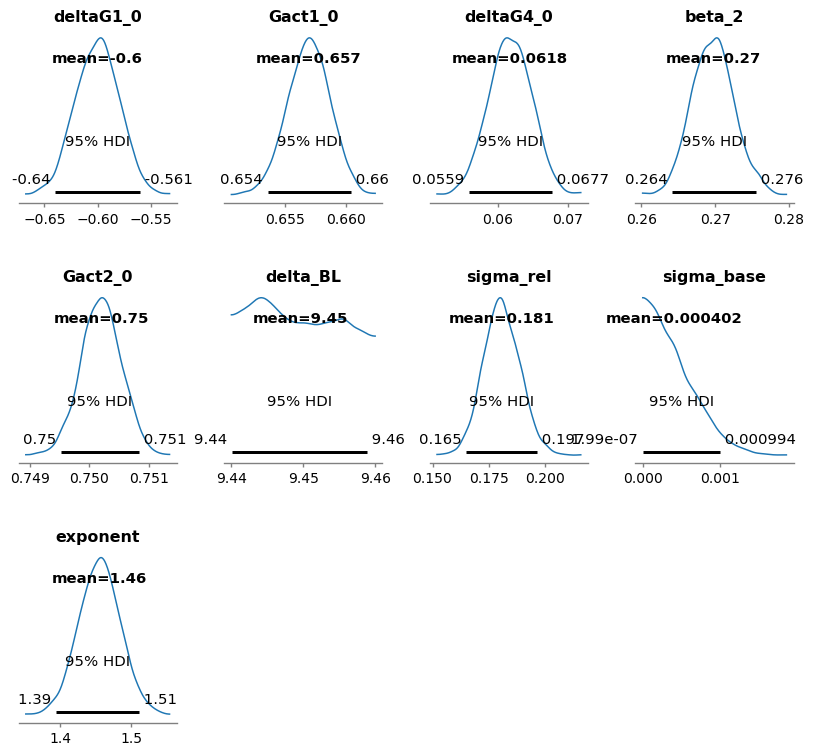

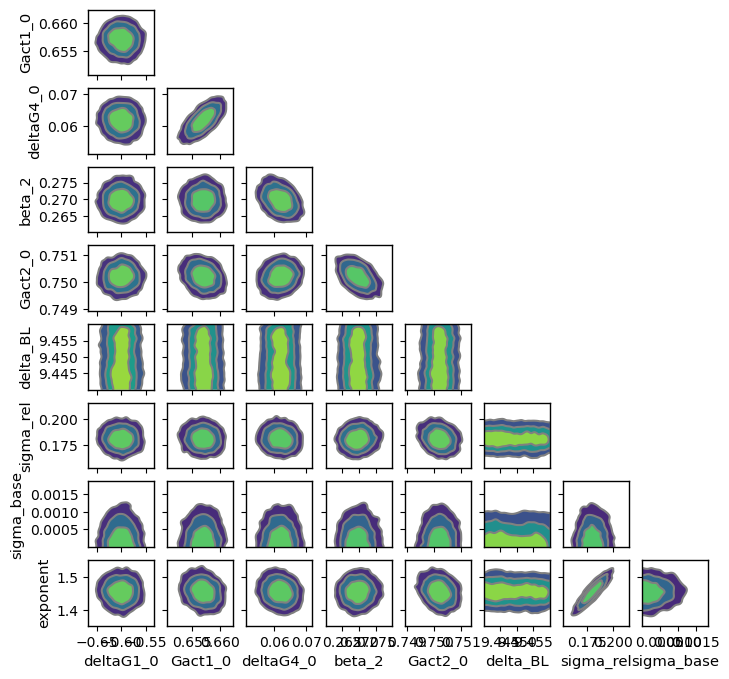

Sampling: [rate]


rate: 0.855


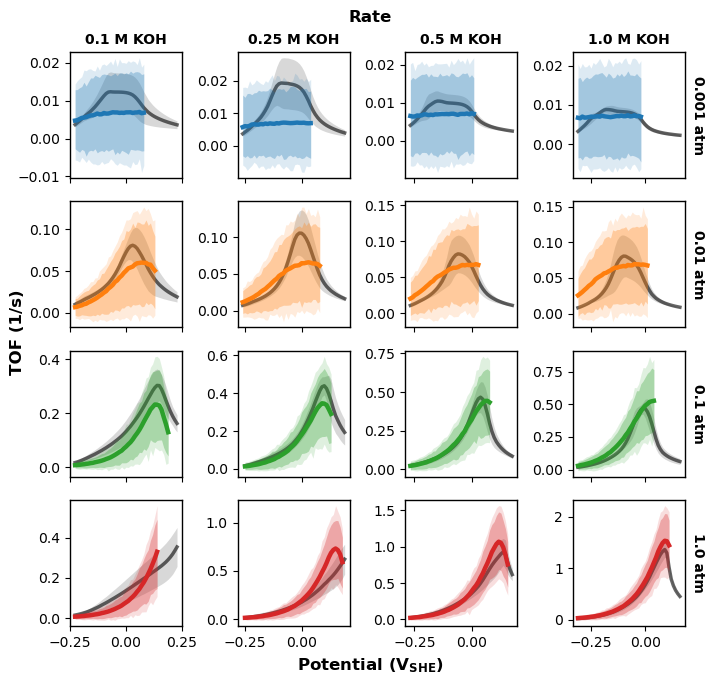

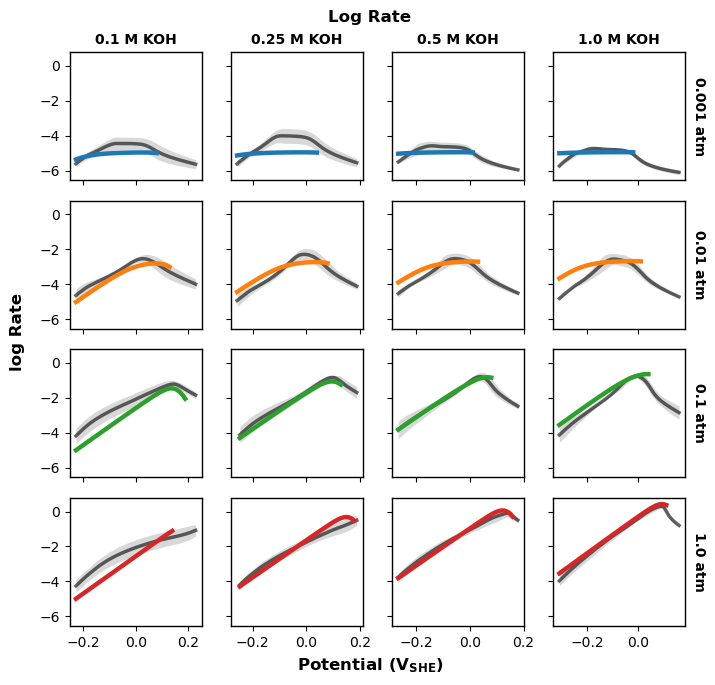

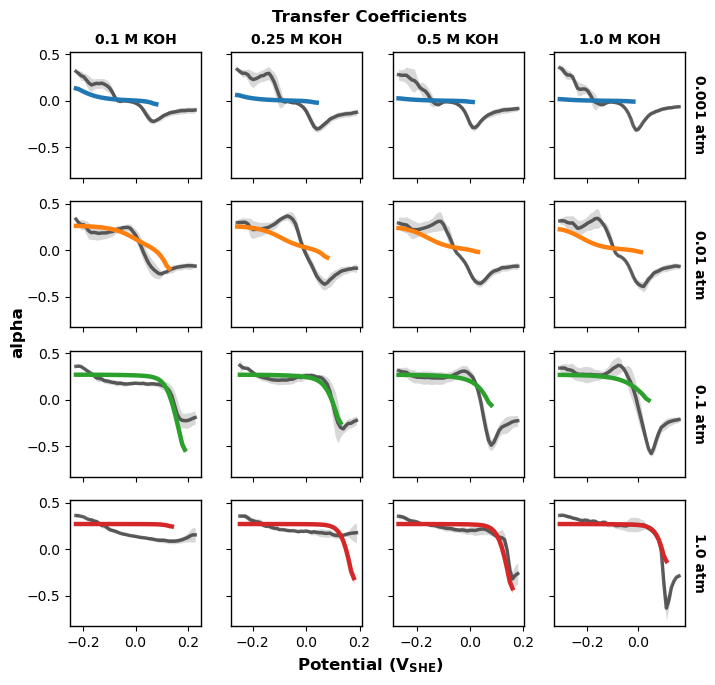

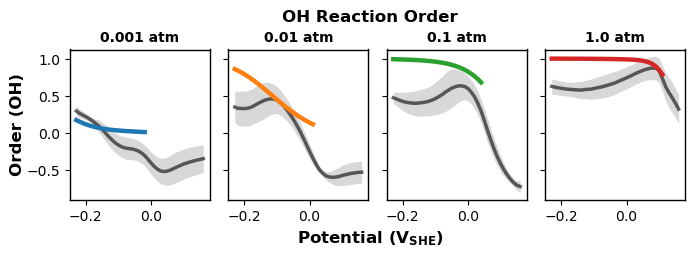

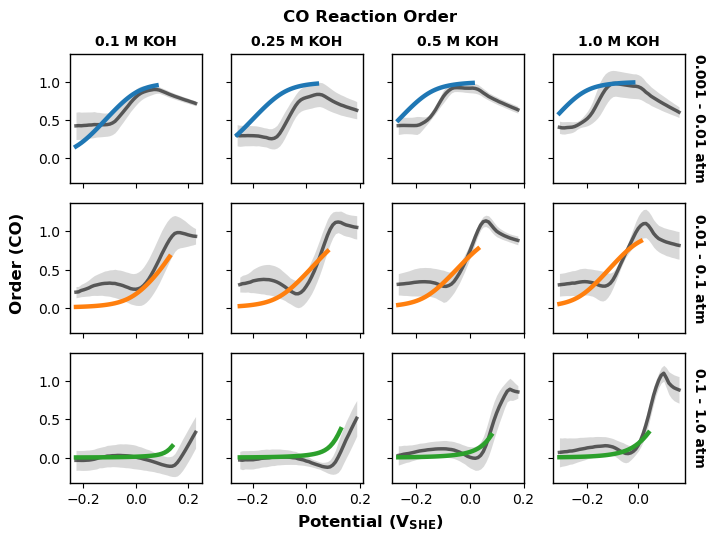

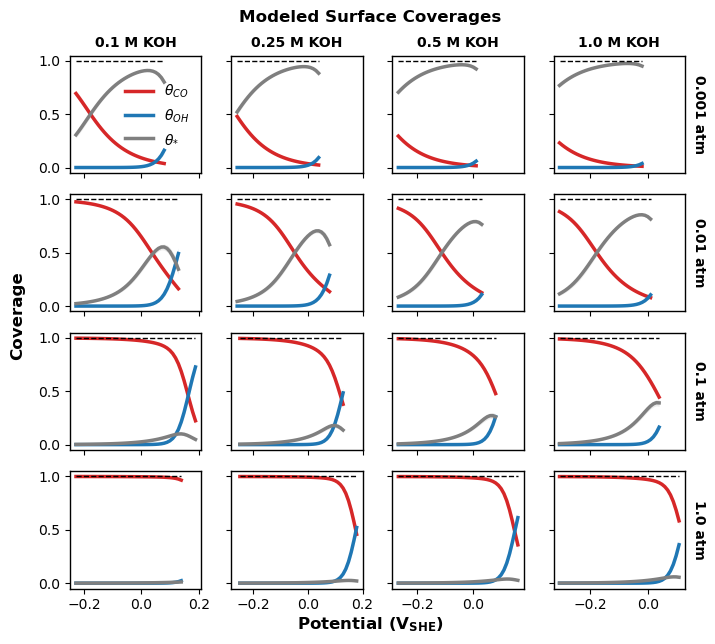

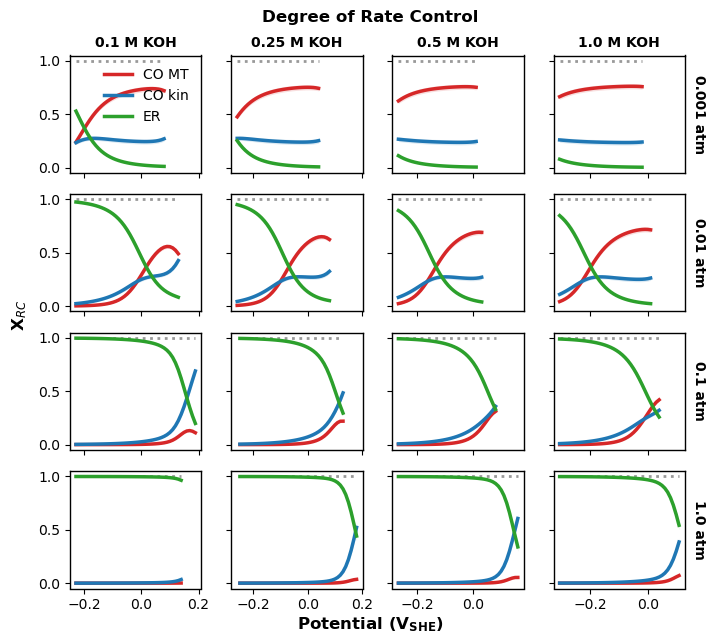

In [7]:
ppc_ER_1_2_kin = plot_posteriors(trace_ER_1_2_kin, ER_1_2_kin)
plot_model_fits(trace_ER_1_2_kin, ppc_ER_1_2_kin); plot_coverages(trace_ER_1_2_kin)
plot_drc(ER_1_2_kin, trace_ER_1_2_kin, perturb_vars=['delta_BL', 'Gact1_0','Gact2_0'], perturb_labels=['CO MT', 'CO kin', 'ER'], 
        var_types={'delta_BL': 'resistance', 'Gact1_0': 'Gact', 'Gact2_0': 'Gact'})

Output()

Interfacial Pressure Range: 0.00019 to 0.99934 atm


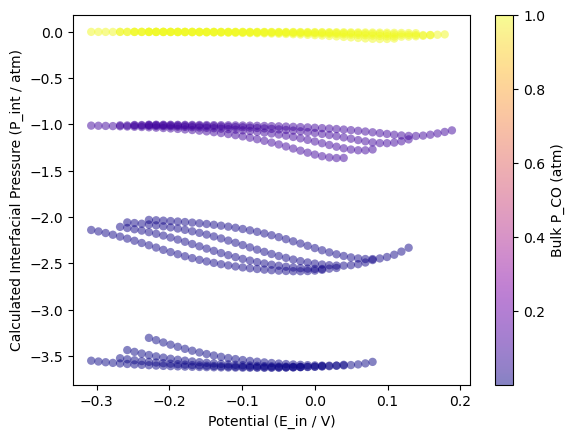

In [8]:
with ER_1_2_kin:
    pm.Deterministic('P_int_save', P_int)

# Pass the posterior group specifically to prevent PyMC's KeyError
trace_updated = pm.compute_deterministics(trace_ER_1_2_kin.posterior, model=ER_1_2_kin)

p_int_samples = trace_updated['P_int_save'].values
p_int_mean = p_int_samples.mean(axis=(0, 1))

print(f"Interfacial Pressure Range: {p_int_samples.min():.5f} to {p_int_samples.max():.5f} atm")

plt.scatter(E_in, np.log10(p_int_mean), c=P_CO_in, cmap='plasma', alpha=0.5, edgecolor='none')
plt.colorbar(label='Bulk P_CO (atm)')
plt.xlabel('Potential (E_in / V)')
plt.ylabel('Calculated Interfacial Pressure (P_int / atm)')
plt.show()

# ER LH 1 2

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.45,15
,3000,0,0.38,15
,3000,0,0.46,15
,3000,0,0.44,3


Computed from 4000 posterior samples and 2324 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  5173.29    72.42
p_loo        9.29        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     2324  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



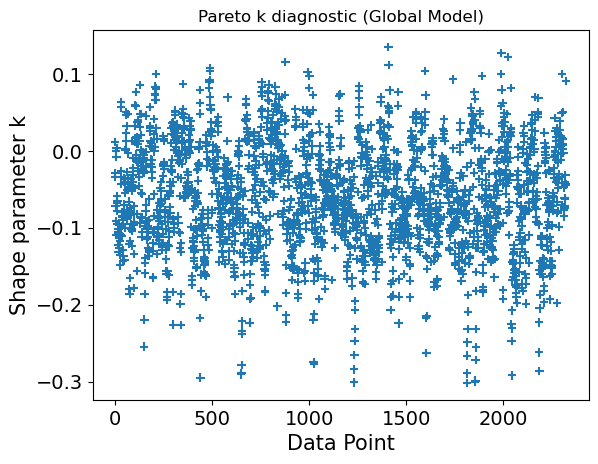

In [9]:
with pm.Model() as ER_LH_1_2:
    '''
    1. CO + * <-> CO* (Fick) (Irr) (SSA)
    2a. CO* + OH- -> COOH* + (e-) (SSA)
    2b. CO* + OH* -> COOH* + * (SSA)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.1) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    Gact2_ER_0 = pm.Normal('Gact2_ER_0', mu=0.75, sigma=0.1) # at 0V_SHE
    Gact2_LH_0 = pm.Normal('Gact2_LH_0', mu=0.75, sigma=0.1)
    delta_BL = pm.TruncatedNormal('delta_BL', mu=10, sigma=5, lower=0) # in microns

    # Thermodynamics 
    deltaG4 = deltaG4_0 - E_in
    Gact2_ER = Gact2_ER_0 - beta_2*E_in
    Gact2_LH = Gact2_LH_0
    log_K4 = -deltaG4/(kb_eV*T)
    log_k1 = log_k1_fick - pt.log(delta_BL)
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)
    log_k2_LH = np.log(kb_J*T/h) - Gact2_LH/(kb_eV*T)

    term_OH = log_K4 + np.log(C_KOH_in)
    gamma_OH_lin = pt.exp(term_OH)
    k1_fwd_lin = pt.exp(log_k1 + np.log(P_CO_in))
    k2_ER_lin = pt.exp(log_k2_ER + np.log(C_KOH_in))
    k2_LH_lin = pt.exp(log_k2_LH + term_OH)
    site_block = 1.0 + gamma_OH_lin
    a_term = k2_ER_lin
    b_term = k2_ER_lin * site_block + k2_LH_lin - k1_fwd_lin
    c_term = - k1_fwd_lin * site_block
    gamma_CO_lin = (-b_term + pt.sqrt(b_term**2 - 4 * a_term * c_term)) / (2 * a_term)
    term_CO = pt.log(gamma_CO_lin)
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta
    
    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))
    theta_empty = pm.Deterministic('theta_empty', pt.exp(log_theta))

    # Rate expression
    log_rate_ER = log_k2_ER + np.log(C_KOH_in) + log_theta_CO
    log_rate_LH = log_k2_LH + log_theta_CO + log_theta_OH
    log_rate = pt.logaddexp(log_rate_ER, log_rate_LH)
    rate = observables(log_rate) 

trace_ER_LH_1_2, loo_ER_LH_1_2 = fit_and_evaluate(ER_LH_1_2)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG4_0   0.086  0.003   0.081    0.091      0.000    0.000    2079.0    2049.0   1.00
Gact2_ER_0  0.748  0.000   0.747    0.748      0.000    0.000    1931.0    2311.0   1.00
Gact2_LH_0  0.765  0.026   0.740    0.796      0.001    0.004     827.0     321.0   1.01
beta_2      0.274  0.003   0.268    0.280      0.000    0.000    2210.0    2176.0   1.00
delta_BL    9.461  0.218   9.054    9.872      0.004    0.004    3648.0    2669.0   1.00
sigma_rel   0.211  0.010   0.193    0.230      0.000    0.000    1823.0    2120.0   1.00
sigma_base  0.000  0.000   0.000    0.001      0.000    0.000    2705.0    1696.0   1.00
exponent    1.597  0.031   1.535    1.650      0.001    0.001    1814.0    2360.0   1.00


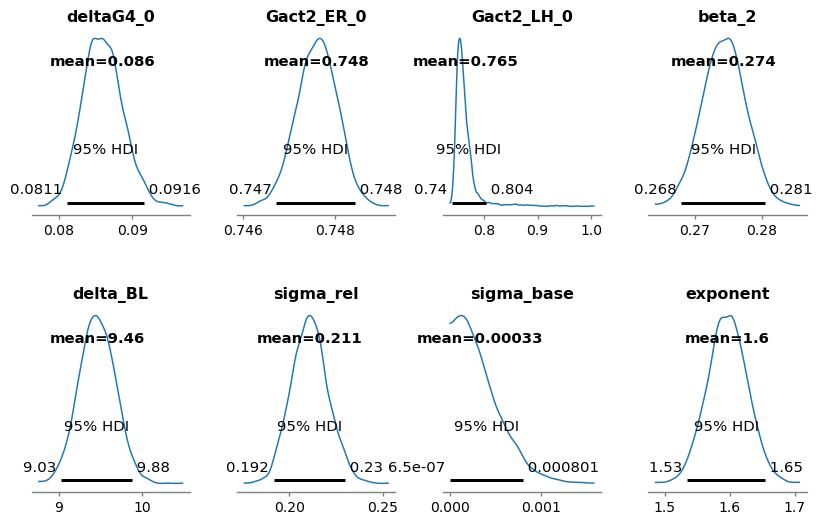

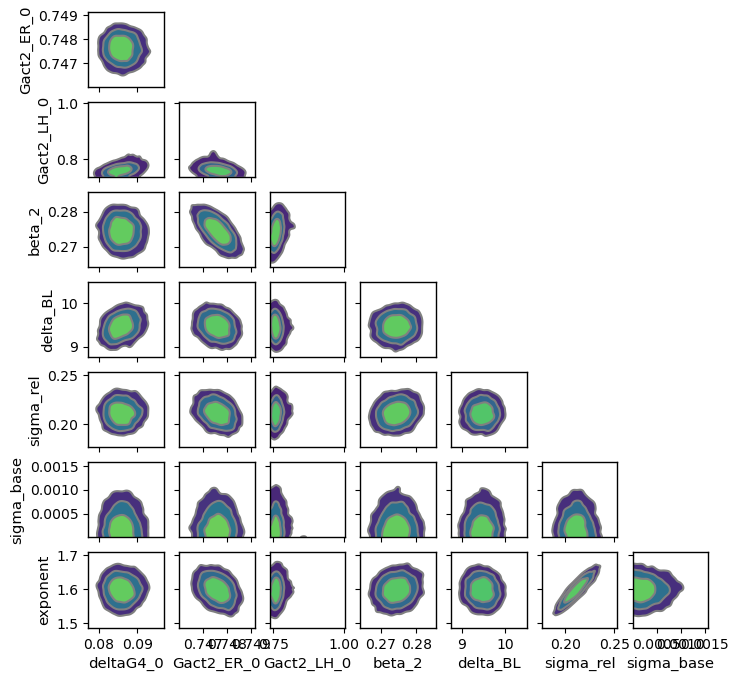

Sampling: [rate]


rate: 0.833


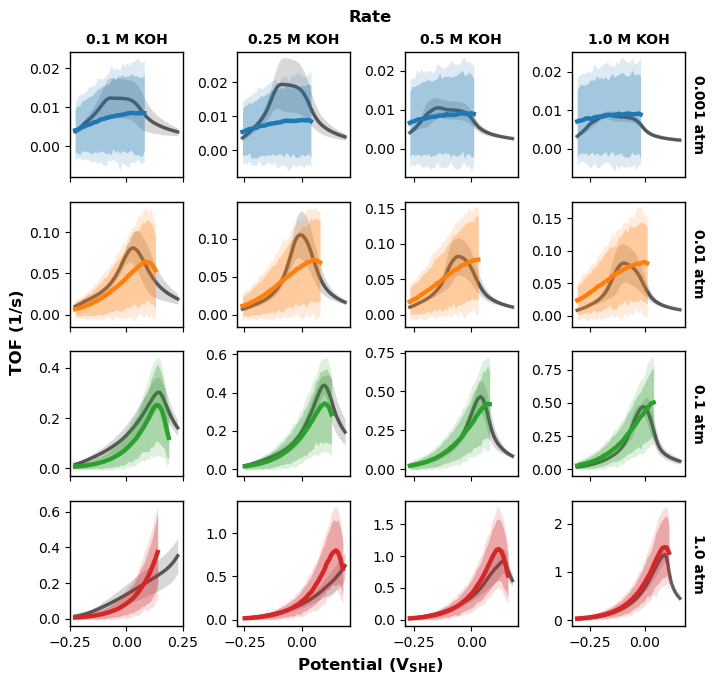

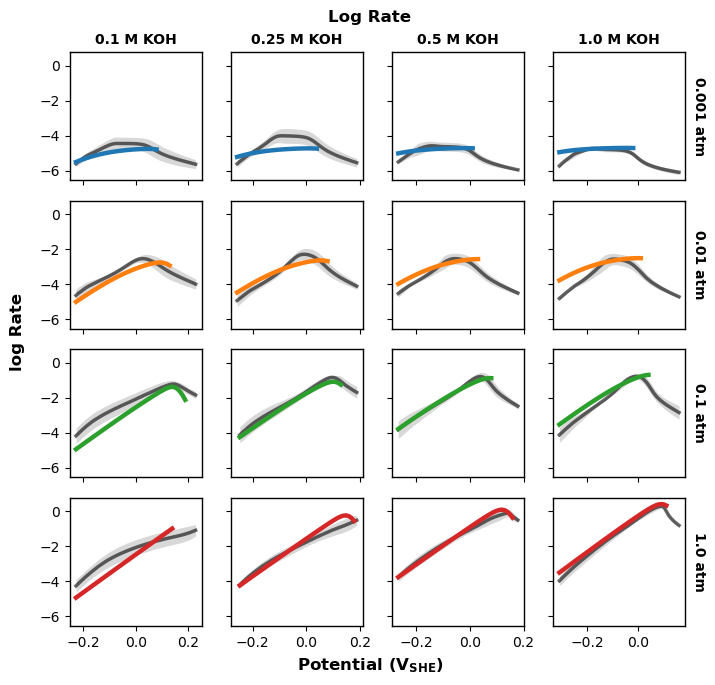

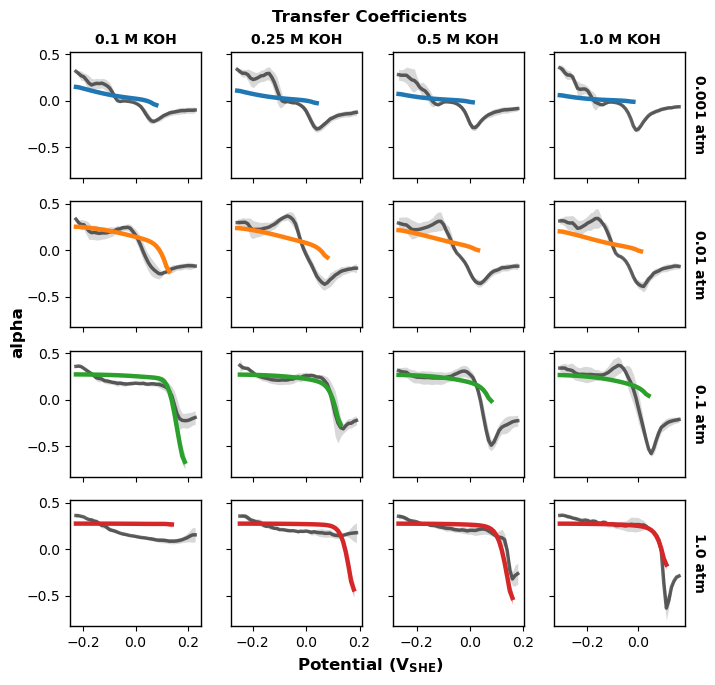

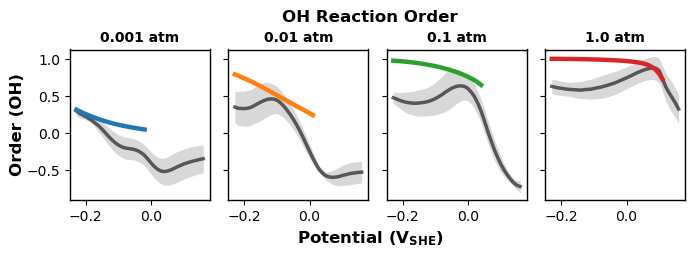

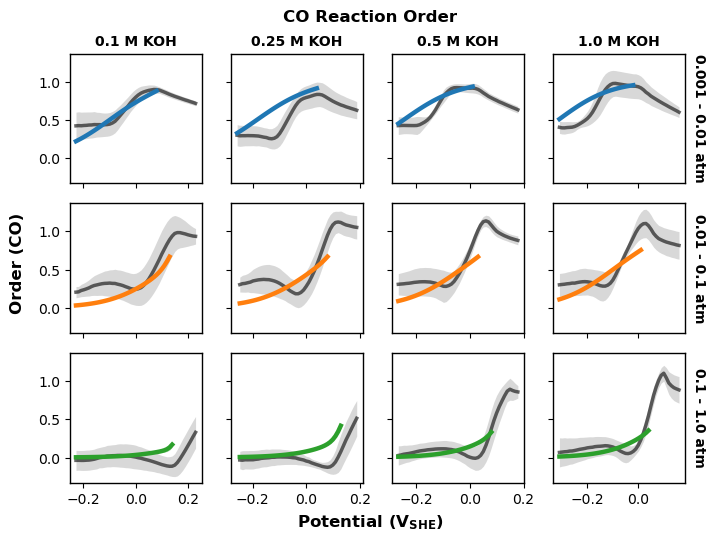

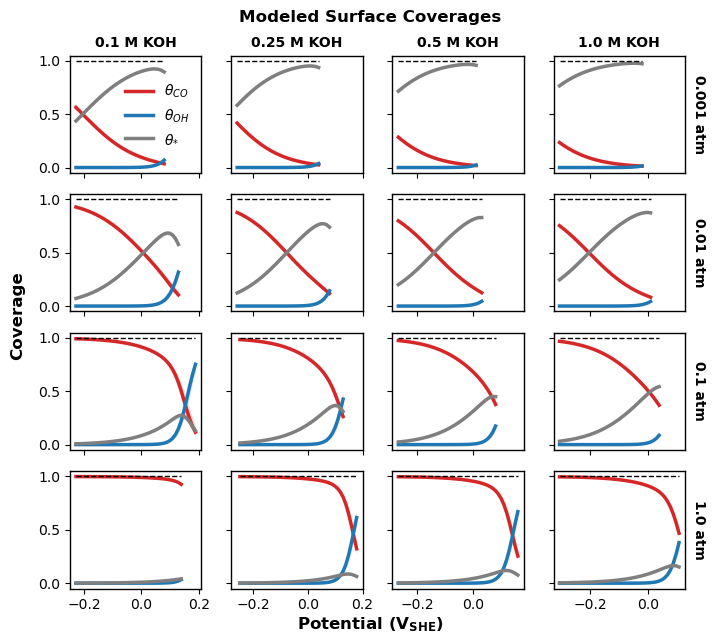

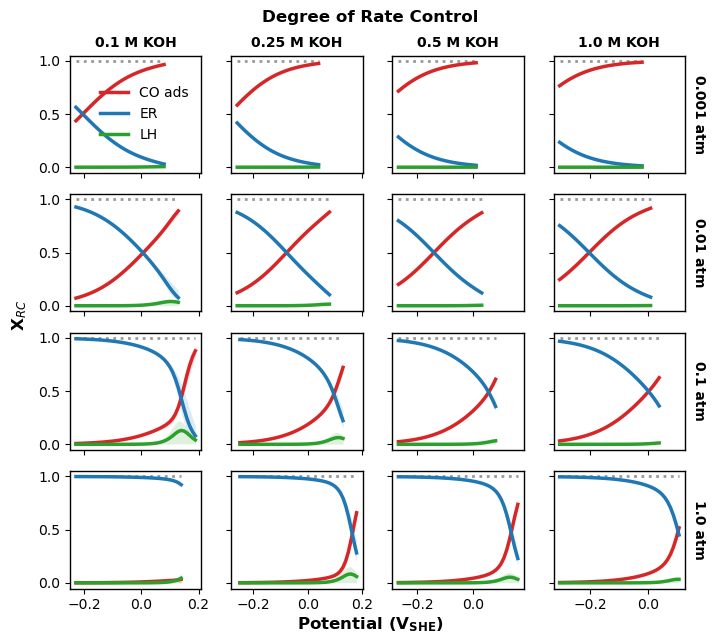

In [10]:
ppc_ER_LH_1_2 = plot_posteriors(trace_ER_LH_1_2, ER_LH_1_2)
plot_model_fits(trace_ER_LH_1_2, ppc_ER_LH_1_2); plot_coverages(trace_ER_LH_1_2)
plot_drc(ER_LH_1_2, trace_ER_LH_1_2, perturb_vars=['delta_BL', 'Gact2_ER_0', 'Gact2_LH_0'], perturb_labels=['CO ads', 'ER', 'LH'], 
         var_types={'delta_BL': 'resistance', 'Gact2_ER_0': 'Gact', 'Gact2_LH_0': 'Gact'})

# Comparison

            rank     elpd_loo      p_loo   elpd_diff  weight         se        dse  warning scale
ER_1_2         0  5169.679202   8.301038    0.000000     1.0  72.583014   0.000000    False   log
ER_1_2_kin     1  5111.079282   7.852416   58.599920     0.0  69.881576  10.023128    False   log
ER_2           2  4569.122044  12.282338  600.557158     0.0  64.859826  32.461554    False   log


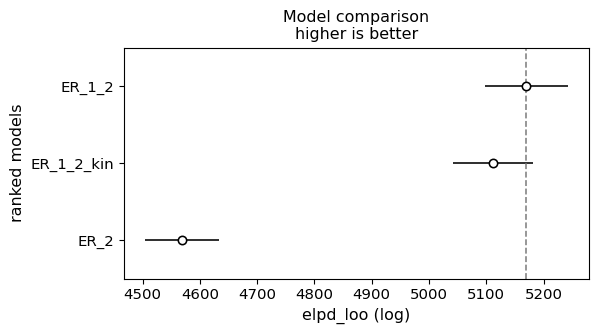

In [11]:
comparison_dict = {
    "ER_2": loo_ER_2,
    "ER_1_2": loo_ER_1_2,
    # "ER_LH_1_2": loo_ER_LH_1_2,
    "ER_1_2_kin": loo_ER_1_2_kin
}

comp_df = az.compare(comparison_dict, ic="loo", method="stacking")
print(comp_df)
az.plot_compare(comp_df, insample_dev=False)
plt.show()